In [1]:
#!sudo apt-get update
# Instala LaTeX (texlive) para que matplotlib pueda renderizar texto con usetex=True
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt  # graficas

import matplotlib.colors as mcolors  # utilidades de color (no se usa directamente aqui)

import numpy as np  # arreglos y algebra lineal en CPU (sin autodiff)

# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": True,            # usar LaTeX real para renderizar texto/formulas
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

# --- JAX ---
import jax                         # libreria de autodiff + compilacion 
import jax.numpy as jnp            # tipo NumPy, pero con arreglos que JAX puede diferenciar
from jax import grad, jit, vmap    # grad: deriva funciones; jit: compila para acelerar; vmap: vectoriza sin loops explicitos

print('Configuracion OK')

Configuracion OK


In [74]:
# Carga de datos

data = np.load('datos_5628.npz')
xdata = data['X']
ydata = data['y']
tdata = data['t']

#Extraemos una señal de cada régimen
x0 = xdata[3]
x1 = xdata[0]
x2 = xdata[4]

data.close()



### Capa Fourier:

Sea $\eta:= \frac{2 \pi}{256}$. Sabemos que la matriz $\text{DFT}$ para secuencias de 256 elementos es

$$ 
\begin{align*}
    \text{DFT} &= \begin{bmatrix}
		e^{-i \cdot \eta \cdot 0 \cdot 0} & e^{-i \cdot\eta \cdot 0 \cdot 1} & \cdots & e^{-i \cdot\eta \cdot 0 \cdot 255} \\
			e^{-i \cdot\eta \cdot 1 \cdot 0} & e^{-i \cdot\eta \cdot 1 \cdot 1} & \cdots & e^{-i \cdot\eta \cdot 1 \cdot 255} \\
			\vdots & \vdots &  & \vdots \\
			e^{-i \cdot\eta \cdot 255 \cdot 0} & e^{-i \cdot\eta \cdot 255 \cdot 1} & \cdots & e^{-i \cdot\eta \cdot 255 \cdot 0}
		\end{bmatrix} \\& = 
        \begin{bmatrix}
        \cos(\eta \cdot 0 \cdot 0) & \cos(\eta \cdot 0 \cdot 1) & \cdots & \cos(\eta \cdot 0 \cdot 255) \\
        \cos(\eta \cdot 1 \cdot 0) & \cos(\eta \cdot 1 \cdot 1) & \cdots & \cos(\eta \cdot 1 \cdot 255) \\
        \vdots & \vdots & \ddots & \vdots \\
        \cos(\eta \cdot 255 \cdot 0) & \cos(\eta \cdot 255 \cdot 1) & \cdots & \cos(\eta \cdot 255 \cdot 255)
        \end{bmatrix} - i \begin{bmatrix}
        \sin(\eta \cdot 0 \cdot 0) & \sin(\eta \cdot 0 \cdot 1) & \cdots & \sin(\eta \cdot 0 \cdot 255) \\
        \sin(\eta \cdot 1 \cdot 0) & \sin(\eta \cdot 1 \cdot 1) & \cdots & \sin(\eta \cdot 1 \cdot 255) \\
        \vdots & \vdots & \ddots & \vdots \\
        \sin(\eta \cdot 255 \cdot 0) & \sin(\eta \cdot 255 \cdot 1) & \cdots & \sin(\eta \cdot 255 \cdot 255)
        \end{bmatrix}

    \end{align*}
$$

En ` makeFourierMatrix` construimos la siguiente matriz:

$$ M = \begin{bmatrix}
			\sin( \eta \cdot 1 \cdot 0) & \sin( \eta \cdot 1 \cdot 1) & \cdots & \sin( \eta \cdot 1 \cdot 255) \\
			\sin( \eta \cdot 2 \cdot 0) & \sin( \eta \cdot 2 \cdot 1) & \cdots & \sin( \eta \cdot 2 \cdot 255) \\
			\vdots & \vdots &  & \vdots  \\
			\sin( \eta \cdot 15 \cdot 0) & \sin( \eta \cdot 15 \cdot 1) & \cdots & \sin( \eta \cdot 15 \cdot 255) \\
            & & & & \\
			\cos( \eta \cdot 1 \cdot 0) & \cos( \eta \cdot 1 \cdot 0) & \cdots & \cos( \eta \cdot 1 \cdot 255)	
			\\
			\cos( \eta \cdot 2 \cdot 0) & \cos( \eta \cdot 2 \cdot 1) & \cdots & \cos( \eta \cdot 2 \cdot 255) \\
			\vdots &  &  &  \\
			\cos( \eta \cdot 15 \cdot 0) & \cos( \eta \cdot 15 \cdot 1) & \cdots & \cos( \eta \cdot 15 \cdot 255)
		\end{bmatrix} = \begin{bmatrix} - \text{Im}(\overline{\text{DFT}}) \\ \text{Re}(\overline{\text{DFT}}) \end{bmatrix}
$$
Donde $\overline{\text{DFT}}$ corresponde a las filas $i=1,...,15$ de $\text{DFT}$ esto es, estamos aislando las frecuencias correspondientes a estas filas, e ignorando todas las demás

Usando la función `parse` podemos convertir la salida de `jnp.fft.fft(xs)` (que corresponde a un array de numeros complejos) a este formato separando parte real e imaginaria, lo que nos permite comparar los resultados de la capa y de `fft`

In [62]:
def makeFourierMatrix(k_values: jnp.array,t_values: jnp.array):
    # Inicializar matrices vacias
    sins = jnp.zeros((len(k_values),len(t_values))) 
    cosins = jnp.zeros((len(k_values),len(t_values)))
    for t in range(len(t_values)):
        for k in range(len(k_values)):
            sins= sins.at[k,t].set(jnp.sin(2*jnp.pi*k_values[k]*t_values[t]))
            cosins= cosins.at[k,t].set(jnp.cos(2*jnp.pi*k_values[k]*t_values[t]))
    return jnp.vstack((sins,cosins)) #shape: len(k_values) x len(t_values)

def parse(x: jnp.array):
    # Para traducir la salida de jnp.fft.fft a la salida de la primera capa de la red
    x = jnp.asarray(x)
    im = x.imag
    re = x.real
    return jnp.concatenate((-im, re))

M = makeFourierMatrix(range(1,16),jnp.arange(256) / 256)


In [ ]:
for x,title in zip([x0,x1,x2],['Régimen 1', 'Régimen 2','Régimen 3']): # Es esta la mejor forma de mostrar que coinciden?
    hMat = M @ x # Resultado construido con la capa de Fourier

    hFft = parse(jnp.fft.fft(x)[1:16]) #Resultado (parseado) de las frecuencias correspondientes de fft(xs)

    print(title, '-----------------')
    print("\t Resultado capa Fourier: \n", hMat)  
    print("\t Resultado FFT de jnp: \n", hFft)    
    if jnp.allclose(hMat, hFft, atol=1e-4):
        print('Coinciden')
    else:
        print('No coinciden')

Régimen 1 -----------------
	 Resultado capa Fourier: 
 [ 1.3791037e-01 -1.6407155e-01 -4.5277987e+00 -1.3194311e-01
 -9.5038277e+01  3.2999161e-01 -1.6650413e-01 -3.1818405e+01
 -2.8716579e-02  1.9091439e-01  4.4099706e-01 -7.5428739e-02
  3.4855872e-02 -5.3786505e-02 -1.4919223e-01 -2.7071126e-03
 -1.5408647e-01 -8.2631920e+01  1.2723079e-01  4.7789604e+01
  8.5673027e-02 -1.4455596e-01  5.1027245e+01 -1.4841665e-01
 -2.2360606e-01  3.8901579e-01  1.3900609e-01  6.4217895e-03
  1.5780826e-01 -1.2825337e-01]
	 Resultado FFT de jnp: 
 [ 1.3790895e-01 -1.6407469e-01 -4.5277987e+00 -1.3195564e-01
 -9.5038254e+01  3.2999212e-01 -1.6650735e-01 -3.1818436e+01
 -2.8719023e-02  1.9090760e-01  4.4099298e-01 -7.5427100e-02
  3.4864955e-02 -5.3792514e-02 -1.4919607e-01 -2.7087480e-03
 -1.5408863e-01 -8.2631912e+01  1.2724835e-01  4.7789627e+01
  8.5671015e-02 -1.4456379e-01  5.1027225e+01 -1.4841254e-01
 -2.2359928e-01  3.8901907e-01  1.3900208e-01  6.4084008e-03
  1.5781401e-01 -1.2825991e-01]


In [78]:
print('Energia media del dataset: ')
print(f'\t  {(xdata**2).mean():.3}')

Energia media del dataset: 
	  0.665


In [ ]:

def genParams(key, fourierFlag):
    kw1, kw2 = jax.random.split(key,2)
    if not fourierFlag:
        params = {
            'W1': jax.random.uniform(kw1, (30,256)),
            'W2': jax.random.uniform(kw2, (256,30))
        }
    elif fourierFlag:
        params = {
            'W1': M,
            'W2': jax.random.uniform(kw2, (256,30))
        }
    return params

def red(params,x):
    # Capa de Fourier
    h = params['W1'] @ x
    h = jnp.tanh(h)
    # Capa final
    h = params['W2'] @ h
    return h # h = W2 * tanh(W1 * x)
    
def loss(params, x, y):
    # x: datos de entrada para la red
    # y: datos objetivo 
    y_hat = red(params,x)
    return jnp.mean((y-y_hat)**2)



In [55]:

key = jax.random.key(0)
paramsFourier = genParams(key,True)
paramsRandom  = genParams(key,False)
print(jnp.shape(paramsFourier['W2']))
xs = xdata[0,:]
ys = xdata[0,:]


(256, 30)


Matrix output shape: [-2.5019118e-01 -8.0661945e-02  1.8173084e-01  5.4835010e-01
 -5.1799215e-02 -6.5445125e-01 -2.9867148e+00  3.3600979e+01
  1.3673589e+01  3.7530331e+01 -7.1545444e+00  6.7423325e+01
 -9.6567011e+00 -5.2702503e+00 -3.8246050e+00 -3.0015011e+00
 -2.6200509e+00 -3.1320381e+00 -3.6422722e+00 -3.9278736e+00
 -5.9868832e+00 -1.0732127e+01  3.3654961e+01  6.3536894e-01
 -2.0638828e+01  1.6809671e+01  6.4875092e+01 -1.4119594e+00
  1.3038343e-01  2.5161108e-01]
FFT output shape: [-2.5018996e-01 -8.0659121e-02  1.8173148e-01  5.4835391e-01
 -5.1803768e-02 -6.5444690e-01 -2.9867337e+00  3.3600964e+01
  1.3673590e+01  3.7530323e+01 -7.1545215e+00  6.7423309e+01
 -9.6567421e+00 -5.2702255e+00 -3.8246045e+00 -3.0015006e+00
 -2.6200500e+00 -3.1320379e+00 -3.6422696e+00 -3.9278746e+00
 -5.9868832e+00 -1.0732134e+01  3.3654984e+01  6.3536465e-01
 -2.0638857e+01  1.6809662e+01  6.4875107e+01 -1.4119991e+00
  1.3040656e-01  2.5161055e-01]
Are they close? True


In [57]:
print('aosdhaods',jnp.shape(paramsFourier['W2']))

print(f'Loss inicial: {loss(paramsFourier, xs, ys):.4f}')

aosdhaods (256, 30)
Loss inicial: 12.5787


In [58]:
h = red(paramsFourier,xs)
print(jnp.shape(h), '\n')

print(jnp.mean((h-ys)**2))

hfft = jnp.fft.fft(xs)


(256,) 

12.578714


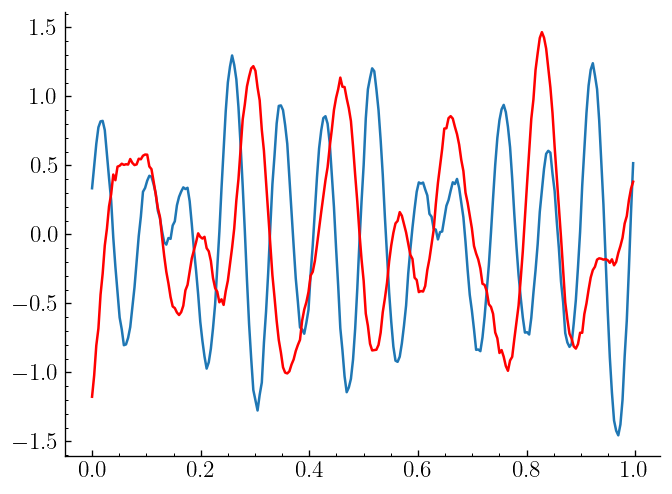

In [59]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,1)
ax.plot(tdata, xdata[0])
ax.plot(tdata, xdata[1], color = 'r')


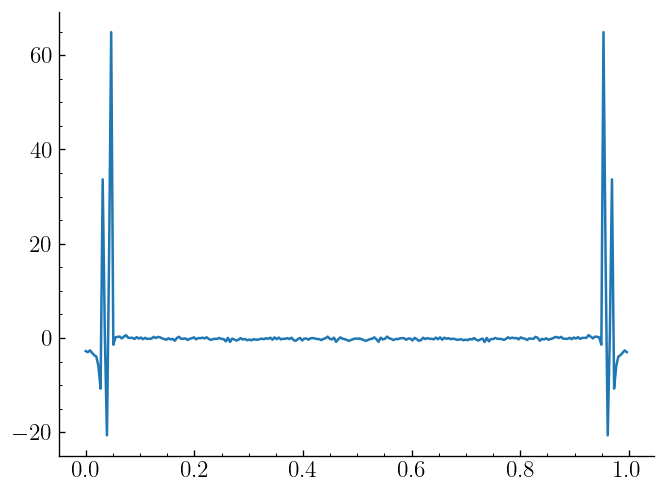

In [60]:
fig,ax = plt.subplots(1,1)
ax.plot(tdata, hfft)